# Task 3 — Evaluation
### INFO-H-515 Big Data: Distributed Data Management and Scalable Analytics
**Environment:** Google Colab  |  **Branch:** evaluation

This notebook evaluates the Topic→Retrieve pipeline (Task 2) using a **manually annotated**
evaluation dataset (`eval_set.json`) with 10 topics drawn from the 8 course PDFs.

**Relevance is page-level**: a retrieved chunk is relevant if its `(source_pdf, page_num)` pair
appears in the human-annotated gold pages for that topic — fully strategy-agnostic.

Metrics: **precision@k**, **recall@k**, **NDCG@k**, **MRR** for k ∈ {2, 5, 8}
across 3 embedding strategies × 2 similarity metrics.

In [1]:
!apt-get install -y -qq default-jre > /dev/null 2>&1
%pip install -q pyspark sentence-transformers gensim scikit-learn pyarrow

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 62.1 MB/s eta 0:00:00


In [2]:
from google.colab import drive
drive.mount('/content/drive' , force_remount=True)

Mounted at /content/drive


In [3]:
from google.colab import userdata

In [4]:
import os

# ── Paths (must match Task 1 output) ────────────────────────────────────
INPUT_DIR     = "/content/drive/MyDrive/DDM/distributed-retrieval-augmented-generation-team-18/processed_data"
OUTPUT_DIR    = "/content/drive/MyDrive/DDM/distributed-retrieval-augmented-generation-team-18/task3_output"
EVAL_SET_PATH = "/content/drive/MyDrive/DDM/distributed-retrieval-augmented-generation-team-18/eval_set.json"

# ── Retrieval evaluation ─────────────────────────────────────────────────
K_VALUES              = [2, 5, 8]
EMBEDDING_STRATEGIES  = ['sbert', 'tfidf', 'word2vec']
SIMILARITY_STRATEGIES = ['cosine', 'euclidean']

# ── Spark ─────────────────────────────────────────────────────────────────
PARALLELISM = 4

# ── Embedding hyper-params (must match Task 1) ────────────────────────────
SBERT_MODEL    = "all-MiniLM-L6-v2"
WORD2VEC_DIM   = 128
TFIDF_MAX_FEAT = 10_000
TFIDF_SVD_DIM  = 256

## 1. Spark Session

In [5]:
import os, json, re, math, random, gc, subprocess
from typing import List, Dict, Tuple

from pyspark.sql import SparkSession, Row
from pyspark.sql.functions import avg as spark_avg, col

from sentence_transformers import SentenceTransformer
from gensim.models import Word2Vec
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD


def build_spark(parallelism: int = PARALLELISM) -> SparkSession:
    import glob
    if not os.environ.get('JAVA_HOME'):
        try:
            java_bin = subprocess.check_output(['which', 'java'], text=True).strip()
            real = subprocess.check_output(['readlink', '-f', java_bin], text=True).strip()
            os.environ['JAVA_HOME'] = os.path.dirname(os.path.dirname(real))
        except Exception:
            cands = glob.glob('/usr/lib/jvm/java-*')
            if cands:
                os.environ['JAVA_HOME'] = cands[0]
    print(f"JAVA_HOME: {os.environ.get('JAVA_HOME')}")
    return (
        SparkSession.builder
        .appName('INFO-H515 Task3 Evaluation')
        .master(f'local[{parallelism}]')
        .config('spark.default.parallelism',    str(parallelism))
        .config('spark.sql.shuffle.partitions', str(parallelism))
        .config('spark.driver.memory',          '4g')
        .config('spark.ui.showConsoleProgress', 'false')
        .getOrCreate()
    )


spark = build_spark(PARALLELISM)
print(f'Spark version : {spark.version}')
print(f'Parallelism   : {spark.sparkContext.defaultParallelism}')

JAVA_HOME: /usr/lib/jvm/java-17-openjdk-amd64
Spark version : 4.0.2
Parallelism   : 4


## 2. Distance Metrics  *(from scratch)*

In [6]:
def cosine_similarity(a: list, b: list) -> float:
    """Cosine similarity from scratch — no external metric libs."""
    dot    = sum(x * y for x, y in zip(a, b))
    norm_a = sum(x * x for x in a) ** 0.5
    norm_b = sum(y * y for y in b) ** 0.5
    if norm_a == 0.0 or norm_b == 0.0:
        return 0.0
    return dot / (norm_a * norm_b)


def euclidean_distance(a: list, b: list) -> float:
    """Euclidean distance from scratch."""
    return sum((x - y) ** 2 for x, y in zip(a, b)) ** 0.5

## 3. Data Loading
Shared utility — loads any strategy's Parquet into a **cached PySpark RDD**.

In [7]:
def load_chunk_rdd(spark: SparkSession, input_dir: str, strategy: str):
    """Load Task 1 Parquet for the given strategy → cached RDD of dicts."""
    path = os.path.join(input_dir, f'strategy={strategy}')
    df   = spark.read.parquet(path)
    def row_to_dict(row):
        d = row.asDict()
        d['embedding'] = list(d['embedding']) if d['embedding'] else []
        return d
    rdd = df.rdd.map(row_to_dict)
    rdd.cache()
    return rdd

## 4. Query Embedding  *(reused from Task 2)*

In [ ]:
# del _sbert_model, _w2v_model, _tfidf_vec, _tfidf_svd
# gc.collect()

In [8]:
# Models cached globally — loaded/fitted once, reused for all queries
_sbert_model  = None
_w2v_model    = None
_tfidf_vec    = None
_tfidf_svd    = None

def _corpus_texts(rdd) -> list:
    return rdd.map(lambda c: c['chunk_text']).collect()


# SBERT
def embed_query_sbert(q: str) -> list:
    global _sbert_model
    if _sbert_model is None:
        print(f'Loading SBERT {SBERT_MODEL} ...')
        _sbert_model = SentenceTransformer(SBERT_MODEL)
    return _sbert_model.encode([q], convert_to_numpy=True)[0].tolist()


# Word2Vec
def embed_query_word2vec(q: str, rdd) -> list:
    global _w2v_model
    if _w2v_model is None:
        tokenise = lambda t: re.findall(r'[a-z]+', t.lower())
        print('Training Word2Vec on corpus ...')
        _w2v_model = Word2Vec(
            [tokenise(t) for t in _corpus_texts(rdd)],
            vector_size=WORD2VEC_DIM, window=5, min_count=2,
            workers=4, sg=1, epochs=5, seed=42
        )
    tokenise = lambda t: re.findall(r'[a-z]+', t.lower())
    vecs = [_w2v_model.wv[t].tolist() for t in tokenise(q) if t in _w2v_model.wv]
    return [sum(v[i] for v in vecs)/len(vecs) for i in range(WORD2VEC_DIM)] if vecs else [0.0]*WORD2VEC_DIM


# TF-IDF + TruncatedSVD
def embed_query_tfidf(q: str, rdd) -> list:
    global _tfidf_vec, _tfidf_svd
    if _tfidf_vec is None:
        print('Fitting TF-IDF + SVD on corpus ...')
        texts      = _corpus_texts(rdd)
        _tfidf_vec = TfidfVectorizer(max_features=TFIDF_MAX_FEAT, sublinear_tf=True)
        mat        = _tfidf_vec.fit_transform(texts)
        _tfidf_svd = TruncatedSVD(n_components=TFIDF_SVD_DIM, random_state=42).fit(mat)
    return _tfidf_svd.transform(_tfidf_vec.transform([q]))[0].tolist()


# Dispatch
_EMBED_FN = {
    'sbert':    lambda q, rdd: embed_query_sbert(q),
    'word2vec': lambda q, rdd: embed_query_word2vec(q, rdd),
    'tfidf':    lambda q, rdd: embed_query_tfidf(q, rdd),
}

def embed_query(q: str, strategy: str, rdd) -> list:
    return _EMBED_FN[strategy](q, rdd)

## 5. Manual Evaluation Dataset

Gold labels come from `eval_set.json` — a **manually annotated** dataset of 8 topics
drawn from the 8 course PDFs (1-intro, 2-spark, 3-stream_proc, 4-stream_algos,
5-nosql, 6-parallel, mr, recommend).

For each topic, gold evidence is a list of `(source_pdf, page_num)` pairs identified
by reading the actual lecture slides.  A retrieved chunk is **relevant** if its
`(source_pdf, page_num)` appears in that topic's gold pages.

**Why page-level labels?**  They are strategy-agnostic — no embedding model is used
to define relevance, so SBERT, TF-IDF, and Word2Vec are evaluated on equal footing.

In [10]:
def inspect_chunks(source_pdf=None, page_num=None, chunk_id=None, strategy='sbert'):
    """
    Inspect processed chunks to verify gold page annotations.
      - chunk_id given          -> return that exact chunk
      - source_pdf + page_num   -> return all chunks on that page
      - source_pdf only         -> list all distinct page_nums for that PDF
    """

    rdd = load_chunk_rdd(spark, INPUT_DIR, strategy)

    if chunk_id is not None:
        results = rdd.filter(lambda c: c['chunk_id'] == chunk_id).collect()
    elif source_pdf is not None and page_num is not None:
        results = rdd.filter(
            lambda c: c['source_pdf'] == source_pdf and c['page_num'] == page_num
        ).collect()
    elif source_pdf is not None:
        pages = (
            rdd.filter(lambda c: c['source_pdf'] == source_pdf)
               .map(lambda c: c['page_num'])
               .distinct()
               .sortBy(lambda x: x)
               .collect()
        )
        print(f'Pages with chunks in {source_pdf}: {pages}')
        return pages
    else:
        raise ValueError('Provide chunk_id, or source_pdf [+ page_num]')

    if not results:
        print('No chunks found.')
        return []

    for i, c in enumerate(results):
        print(f'─── {i+1}/{len(results)} ─────────────────────────────────────────')
        print(f'  chunk_id  : {c["chunk_id"]}')
        print(f'  source_pdf: {c["source_pdf"]}  |  page_num: {c["page_num"]}')
        print(f'  words     : {len(c["chunk_text"].split())}')
        print(f'  text      :\n{c["chunk_text"][:]}')
        print()
    return results


In [26]:
# inspect_chunks(source_pdf='2-spark.pdf', page_num=20)      # all chunks on page 20
# inspect_chunks(source_pdf='5-nosql.pdf')                   # list all pages with chunks
# inspect_chunks(chunk_id='2-spark.pdf_p20_c0')              # by chunk_id
res = inspect_chunks(source_pdf='recommend.pdf')

Pages with chunks in recommend.pdf: [2, 5, 7, 8, 9, 11, 12, 15, 16, 17, 18, 20, 23, 24, 25, 26, 28, 29, 30, 31, 34, 35, 36, 37, 38, 40, 42, 43, 44, 45, 46]


In [27]:
res = inspect_chunks(source_pdf='recommend.pdf', page_num=5)

─── 1/1 ─────────────────────────────────────────
  chunk_id  : recommend.pdf_p005_c000
  source_pdf: recommend.pdf  |  page_num: 5
  words     : 84
  text      :
collaborative filtering • Idea: if users shared the same interests in the past, they will do it also in the future. • It relies only on ◦ past user behavior(e.g. previous transactions or product ratings) ◦ relationships between usersand interdependencies among products. • Largely used and successful approach (online retail sales) • Issues: ◦ How to find users with similar tastes and what does it mean similar? ◦ What about users for which no buying historyis available? ◦ What about recentitems (not bought yet)?



In [28]:
with open(EVAL_SET_PATH) as f:
    eval_set = json.load(f)

print(f'Loaded {len(eval_set)} topics from eval_set.json\n')
for entry in eval_set:
    n_gold  = len(entry['gold_pages'])
    sources = sorted({p['source_pdf'] for p in entry['gold_pages']})
    print(f"[{entry['topic_id']}] {entry['topic'][:]}")
    print(f"       {n_gold} gold pages  |  from: {sources}")
    print()

Loaded 8 topics from eval_set.json

[t01] Resilient Distributed Datasets (RDDs) in Apache Spark: distributed, immutable, and fault-tolerant properties
       5 gold pages  |  from: ['2-spark.pdf']

[t02] RDD transformations in Apache Spark: map, flatMap, and filter operations
       5 gold pages  |  from: ['2-spark.pdf']

[t03] Big Data definitions
       4 gold pages  |  from: ['1-intro.pdf']

[t04] Map Reduce mr programming model: map and reduce phases
       4 gold pages  |  from: ['mr.pdf']

[t05] CAP theorem: consistency, availability, and partition tolerance trade-offs in distributed systems
       3 gold pages  |  from: ['5-nosql.pdf']

[t06] MINI-BATCHING IN SPARK STREAMING
       3 gold pages  |  from: ['3-stream_proc.pdf']

[t07] Filtering Analysis
       4 gold pages  |  from: ['4-stream_algos.pdf']

[t08] Collaborative filtering for recommendation systems: user based, past user behavior, item based, nearest-neighbor, and latent factor models
       5 gold pages  |  from: ['

## 6. Retrieval Metrics  *(pure Python)*

- **precision@k** = |relevant ∩ top-k| / k
- **recall@k**    = |relevant ∩ top-k| / |relevant|
- **NDCG@k**      = DCG / IDCG — rewards relevant results ranked higher
- **MRR**         = mean of 1/rank of the first relevant result per topic

Relevant = retrieved chunk's `(source_pdf, page_num)` ∈ gold pages for the topic.

In [29]:
def precision_at_k(retrieved_ids: list, relevant_ids: set, k: int) -> float:
    hits = sum(1 for cid in retrieved_ids[:k] if cid in relevant_ids)
    return hits / k


def recall_at_k(retrieved_ids: list, relevant_ids: set, k: int) -> float:
    if not relevant_ids:
        return 0.0
    hits = sum(1 for cid in retrieved_ids[:k] if cid in relevant_ids)
    return hits / len(relevant_ids)


def ndcg_at_k(retrieved_ids: list, relevant_ids: set, k: int) -> float:
    """Normalized Discounted Cumulative Gain at k."""
    dcg  = sum(1.0 / math.log2(i + 2) for i, cid in enumerate(retrieved_ids[:k]) if cid in relevant_ids)
    idcg = sum(1.0 / math.log2(i + 2) for i in range(min(len(relevant_ids), k)))
    return dcg / idcg if idcg > 0 else 0.0


def reciprocal_rank(retrieved_ids: list, relevant_ids: set) -> float:
    """Reciprocal rank of the first relevant result (for MRR aggregation)."""
    for i, cid in enumerate(retrieved_ids):
        if cid in relevant_ids:
            return 1.0 / (i + 1)
    return 0.0


# Unit tests
assert precision_at_k(['a', 'b', 'c', 'd'], {'a', 'c', 'e'}, k=2) == 0.5
assert abs(recall_at_k(['a', 'b', 'c', 'd'], {'a', 'c', 'e'}, k=4) - 2/3) < 1e-9
assert ndcg_at_k(     ['a', 'b', 'c'],       {'a', 'c'},       k=3) > 0
assert reciprocal_rank(['x', 'a', 'b'],       {'a'})           == 0.5
print('Metric unit tests passed.')

Metric unit tests passed.


In [30]:
def retrieve_top_chunks(spark, rdd, query_embedding: list, sim_strategy: str, k: int):
    """
    Retrieve top-k chunks using PySpark broadcast + map + sortBy.
    Returns list of (score, chunk_dict) sorted best-first.
    """
    if sim_strategy == 'cosine':
        score_fn  = cosine_similarity
        ascending = False
    else:
        score_fn  = euclidean_distance
        ascending = True

    bc_q = spark.sparkContext.broadcast(query_embedding)
    top  = (
        rdd
        .map(lambda c: (score_fn(bc_q.value, c['embedding']), c))
        .sortBy(lambda x: x[0], ascending=ascending)
        .take(k)
    )
    bc_q.unpersist()
    return top

## 7. Evaluation Loop

For each **(topic × embedding strategy × similarity metric)** combination:
1. Load the strategy's Parquet RDD with PySpark.
2. Embed the **topic string** as a query using the matching strategy.
3. `retrieve_top_chunks` — PySpark broadcast + map + sortBy.
4. Map retrieved chunks to `(source_pdf, page_num)` page identifiers.
5. Check relevance against the topic's gold pages set (strategy-agnostic).
6. Compute **precision@k**, **recall@k**, **NDCG@k**, **MRR** for k ∈ {2, 5, 8}.

Results are collected into a PySpark DataFrame for aggregation.

In [31]:
def run_evaluation(eval_set: list):
    """
    Full evaluation loop: topics × strategies × similarity × k values.

    Relevance = page-level: a retrieved chunk is relevant when its
    (source_pdf, page_num) pair is in the topic's manually annotated gold_pages set.

    Returns a Spark DataFrame:
    [topic_id, strategy, similarity, k, precision, recall, ndcg, rr]
    """
    os.makedirs(OUTPUT_DIR, exist_ok=True)
    rows = []

    for emb_strat in EMBEDDING_STRATEGIES:
        print(f'\n=== Embedding strategy: {emb_strat} ===')
        rdd = load_chunk_rdd(spark, INPUT_DIR, emb_strat)

        for sim_strat in SIMILARITY_STRATEGIES:
            print(f'  Similarity: {sim_strat}')

            for entry in eval_set:
                topic_id = entry['topic_id']
                query    = entry['topic']

                # Gold set: (source_pdf, page_num) tuples — no embedding involved
                gold_pages = frozenset(
                    (p['source_pdf'], p['page_num'])
                    for p in entry['gold_pages']
                )

                q_emb = embed_query(query, emb_strat, rdd)

                top_chunks = retrieve_top_chunks(
                    spark, rdd, q_emb, sim_strat, max(K_VALUES)
                )
                retrieved_pages = [
                    (ch['source_pdf'], ch['page_num'])
                    for _, ch in top_chunks
                ]
                rr = reciprocal_rank(retrieved_pages, gold_pages)

                for k in K_VALUES:
                    rows.append(Row(
                        topic_id  = topic_id,
                        strategy  = emb_strat,
                        similarity= sim_strat,
                        k         = k,
                        precision = float(precision_at_k(retrieved_pages, gold_pages, k)),
                        recall    = float(recall_at_k(retrieved_pages, gold_pages, k)),
                        ndcg      = float(ndcg_at_k(retrieved_pages, gold_pages, k)),
                        rr        = float(rr),
                    ))

            print(f'    {len(eval_set)} topics done.')
        rdd.unpersist()

    return spark.createDataFrame(rows)

## 8. Run Evaluation

In [32]:
metrics_df = run_evaluation(eval_set)
metrics_df.cache()
metrics_df.show(truncate=False)


=== Embedding strategy: sbert ===
  Similarity: cosine
Loading SBERT all-MiniLM-L6-v2 ...


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

    8 topics done.
  Similarity: euclidean
    8 topics done.

=== Embedding strategy: tfidf ===
  Similarity: cosine
Fitting TF-IDF + SVD on corpus ...
    8 topics done.
  Similarity: euclidean
    8 topics done.

=== Embedding strategy: word2vec ===
  Similarity: cosine
Training Word2Vec on corpus ...
    8 topics done.
  Similarity: euclidean
    8 topics done.
+--------+--------+----------+---+---------+------------------+-------------------+-------------------+
|topic_id|strategy|similarity|k  |precision|recall            |ndcg               |rr                 |
+--------+--------+----------+---+---------+------------------+-------------------+-------------------+
|t01     |sbert   |cosine    |2  |0.5      |0.2               |0.38685280723454163|0.5                |
|t01     |sbert   |cosine    |5  |0.2      |0.2               |0.21398626473452756|0.5                |
|t01     |sbert   |cosine    |8  |0.25     |0.4               |0.3347975674340217 |0.5                |
|t02    

## 9. Results

Average precision@k, recall@k, NDCG@k, and MRR per (strategy, similarity, k).

In [33]:
from pyspark.sql.functions import avg as spark_avg, round as spark_round

summary_df = (
    metrics_df
    .groupBy('strategy', 'similarity', 'k')
    .agg(
        spark_round(spark_avg('precision'), 4).alias('avg_precision'),
        spark_round(spark_avg('recall'),    4).alias('avg_recall'),
        spark_round(spark_avg('ndcg'),      4).alias('avg_ndcg'),
        spark_round(spark_avg('rr'),        4).alias('mrr'),
    )
    .orderBy('strategy', 'similarity', 'k')
)
summary_df.show(truncate=False)

# Also show per-topic breakdown
per_topic_df = (
    metrics_df
    .filter(col('k') == 5)
    .groupBy('topic_id', 'strategy', 'similarity')
    .agg(
        spark_round(spark_avg('precision'), 4).alias('p@5'),
        spark_round(spark_avg('recall'),    4).alias('r@5'),
        spark_round(spark_avg('ndcg'),      4).alias('ndcg@5'),
    )
    .orderBy('strategy', 'similarity', 'topic_id')
)
per_topic_df.show(truncate=False)

os.makedirs(OUTPUT_DIR, exist_ok=True)
out_path = os.path.join(OUTPUT_DIR, 'retrieval_metrics.json')
with open(out_path, 'w') as f:
    json.dump(summary_df.toPandas().to_dict(orient='records'), f, indent=2)
print(f'Results saved → {out_path}')

+--------+----------+---+-------------+----------+--------+------+
|strategy|similarity|k  |avg_precision|avg_recall|avg_ndcg|mrr   |
+--------+----------+---+-------------+----------+--------+------+
|sbert   |cosine    |2  |0.5          |0.2688    |0.5283  |0.7232|
|sbert   |cosine    |5  |0.325        |0.4396    |0.4702  |0.7232|
|sbert   |cosine    |8  |0.2656       |0.5521    |0.5311  |0.7232|
|sbert   |euclidean |2  |0.5          |0.2688    |0.5283  |0.7232|
|sbert   |euclidean |5  |0.325        |0.4396    |0.4702  |0.7232|
|sbert   |euclidean |8  |0.2656       |0.5521    |0.5311  |0.7232|
|tfidf   |cosine    |2  |0.0          |0.0       |0.0     |0.0   |
|tfidf   |cosine    |5  |0.0          |0.0       |0.0     |0.0   |
|tfidf   |cosine    |8  |0.0          |0.0       |0.0     |0.0   |
|tfidf   |euclidean |2  |0.0          |0.0       |0.0     |0.0   |
|tfidf   |euclidean |5  |0.0          |0.0       |0.0     |0.0   |
|tfidf   |euclidean |8  |0.0          |0.0       |0.0     |0.0

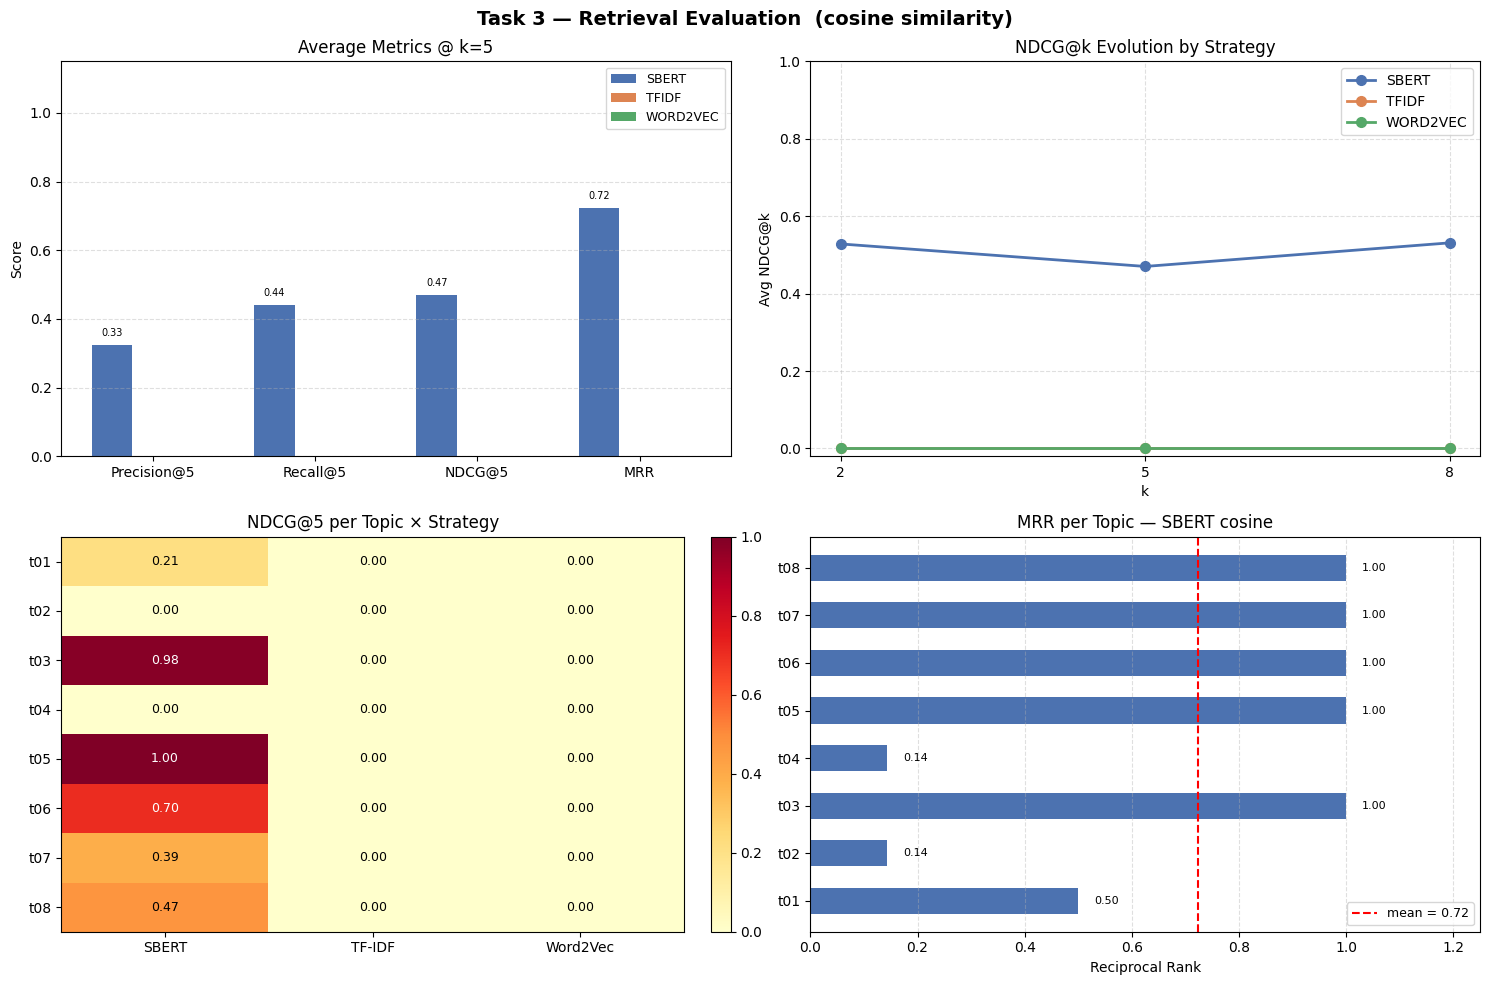

Figure saved → /content/drive/MyDrive/DDM/distributed-retrieval-augmented-generation-team-18/task3_output/retrieval_metrics.png


In [34]:
import matplotlib.pyplot as plt
import numpy as np

# ── pandas conversion ──────────────────────────────────────────────────────
sum_pd  = summary_df.toPandas()
full_pd = metrics_df.toPandas()

# cosine only (euclidean identical for sbert; tfidf/word2vec all-zero anyway)
sum_cos  = sum_pd[sum_pd['similarity'] == 'cosine'].copy()
full_cos = full_pd[full_pd['similarity'] == 'cosine'].copy()
for c in ['avg_precision', 'avg_recall', 'avg_ndcg', 'mrr']:
    sum_cos[c] = sum_cos[c].astype(float)
for c in ['precision', 'recall', 'ndcg', 'rr']:
    full_cos[c] = full_cos[c].astype(float)

STRATEGIES = ['sbert', 'tfidf', 'word2vec']
COLORS     = {'sbert': '#4C72B0', 'tfidf': '#DD8452', 'word2vec': '#55A868'}

fig, axes = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle('Task 3 — Retrieval Evaluation  (cosine similarity)', fontsize=14, fontweight='bold')

# ── 1. Grouped bars: avg metrics @ k=5 per strategy ───────────────────────
ax = axes[0, 0]
k5     = sum_cos[sum_cos['k'] == 5]
mcols  = ['avg_precision', 'avg_recall', 'avg_ndcg', 'mrr']
mlbls  = ['Precision@5', 'Recall@5', 'NDCG@5', 'MRR']
x, w   = np.arange(len(mcols)), 0.25
for i, strat in enumerate(STRATEGIES):
    row  = k5[k5['strategy'] == strat].iloc[0]
    vals = [float(row[m]) for m in mcols]
    bars = ax.bar(x + i * w, vals, w, label=strat.upper(), color=COLORS[strat])
    for bar, v in zip(bars, vals):
        if v > 0:
            ax.text(bar.get_x() + bar.get_width() / 2, v + 0.02,
                    f'{v:.2f}', ha='center', va='bottom', fontsize=7)
ax.set_xticks(x + w); ax.set_xticklabels(mlbls)
ax.set_ylim(0, 1.15); ax.set_ylabel('Score')
ax.set_title('Average Metrics @ k=5')
ax.legend(fontsize=9); ax.grid(axis='y', linestyle='--', alpha=0.4)

# ── 2. NDCG@k line per strategy ────────────────────────────────────────────
ax = axes[0, 1]
for strat in STRATEGIES:
    sub = sum_cos[sum_cos['strategy'] == strat].sort_values('k')
    ax.plot(sub['k'], sub['avg_ndcg'], marker='o', label=strat.upper(),
            color=COLORS[strat], linewidth=2, markersize=7)
ax.set_xlabel('k'); ax.set_ylabel('Avg NDCG@k')
ax.set_title('NDCG@k Evolution by Strategy')
ax.set_xticks([2, 5, 8]); ax.set_ylim(-0.02, 1.0)
ax.legend(); ax.grid(True, linestyle='--', alpha=0.4)

# ── 3. Per-topic NDCG@5 heatmap ────────────────────────────────────────────
ax = axes[1, 0]
hm = (full_cos[full_cos['k'] == 5][['topic_id', 'strategy', 'ndcg']]
      .pivot(index='topic_id', columns='strategy', values='ndcg')
      [STRATEGIES].sort_index())
im = ax.imshow(hm.values, aspect='auto', cmap='YlOrRd', vmin=0, vmax=1)
ax.set_xticks(range(3)); ax.set_xticklabels(['SBERT', 'TF-IDF', 'Word2Vec'])
ax.set_yticks(range(len(hm))); ax.set_yticklabels(hm.index.tolist())
for i in range(len(hm)):
    for j in range(3):
        v = float(hm.values[i, j])
        ax.text(j, i, f'{v:.2f}', ha='center', va='center',
                fontsize=9, color='white' if v > 0.55 else 'black')
plt.colorbar(im, ax=ax, fraction=0.03, pad=0.04)
ax.set_title('NDCG@5 per Topic × Strategy')

# ── 4. Reciprocal rank per topic (SBERT cosine) ────────────────────────────
ax = axes[1, 1]
rr_df = (full_cos[(full_cos['strategy'] == 'sbert') & (full_cos['k'] == 5)]
         .sort_values('topic_id')[['topic_id', 'rr']])
bars    = ax.barh(rr_df['topic_id'], rr_df['rr'], color=COLORS['sbert'], height=0.55)
mean_rr = rr_df['rr'].mean()
ax.axvline(mean_rr, color='red', linestyle='--', linewidth=1.5,
           label=f'mean = {mean_rr:.2f}')
for bar, (_, row) in zip(bars, rr_df.iterrows()):
    if row['rr'] > 0:
        ax.text(row['rr'] + 0.03, bar.get_y() + bar.get_height() / 2,
                f'{row["rr"]:.2f}', va='center', fontsize=8)
ax.set_xlabel('Reciprocal Rank'); ax.set_xlim(0, 1.25)
ax.set_title('MRR per Topic — SBERT cosine')
ax.legend(fontsize=9); ax.grid(axis='x', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'retrieval_metrics.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Figure saved →', os.path.join(OUTPUT_DIR, 'retrieval_metrics.png'))


## 10. Generation & Grounding Metrics

Two scores computed **without an LLM evaluator** (section 3.2 of the spec forbids using an LLM outside the generator role):

| Score | Method | Measures |
|---|---|---|
| **Correctness** | `cosine_similarity(SBERT(Q+A), SBERT(query))` | Topical relevance of question+answer to the requested topic |
| **Faithfulness** | `\|answer_tokens ∩ cited_chunk_tokens\| / \|answer_tokens\|` | Grounding of the answer in the cited source text (unigram precision, stopwords excluded) |

Both are averaged across the N questions generated per query.
Input: `task2_output/task2_result_<topic_id>.json` produced by Task 2.

In [ ]:
from sentence_transformers import SentenceTransformer

_STOPWORDS = {
    'the','a','an','is','are','was','were','in','of','to','and','or','it',
    'that','this','for','with','on','as','at','be','by','from','not','but',
    'if','its','which','when','their','they','we','can','has','have','been',
    'what','how','why','who','would','could','should','will','do','does','did',
    'our','your','my','his','her','than','then','so','no','each','s','t','i',
}

_sbert_eval = None

def _get_sbert_eval():
    global _sbert_eval
    if _sbert_eval is None:
        print(f'Loading SBERT {SBERT_MODEL} for evaluation ...')
        _sbert_eval = SentenceTransformer(SBERT_MODEL)
    return _sbert_eval


def parse_generated_output(text: str) -> list:
    """Split LLM output on '---' separators and extract Q / A / CITATIONS per block."""
    blocks = [b.strip() for b in re.split(r'-{3,}', text) if b.strip()]
    out = []
    for block in blocks:
        q = re.search(r'Q\s*:\s*(.+?)(?=\nA\s*:|\Z)',         block, re.DOTALL | re.IGNORECASE)
        a = re.search(r'A\s*:\s*(.+?)(?=\nCITATIONS\s*:|\Z)', block, re.DOTALL | re.IGNORECASE)
        c = re.search(r'CITATIONS\s*:\s*(.+?)$',               block, re.DOTALL | re.IGNORECASE)
        if q or a:
            out.append({
                'question':      q.group(1).strip() if q else '',
                'answer':        a.group(1).strip() if a else '',
                'citations_raw': c.group(1).strip() if c else '',
            })
    return out


def parse_citation_indices(citations_raw: str) -> list:
    return [int(m) for m in re.findall(r'\[(\d+)\]', citations_raw)]


def faithfulness_score(answer_text: str, cited_texts: list) -> float:
    """
    Unigram precision: fraction of answer content-words found in the cited chunks.
    Grounded answer → score near 1.  Hallucinated content → score near 0.
    """
    tokens = set(re.findall(r'[a-z]+', answer_text.lower())) - _STOPWORDS
    if not tokens:
        return 0.0
    cited_tokens = set()
    for t in cited_texts:
        cited_tokens |= set(re.findall(r'[a-z]+', t.lower()))
    return len(tokens & cited_tokens) / len(tokens)


def correctness_score(question: str, answer: str, query: str) -> float:
    """
    SBERT cosine similarity between (question + answer) and the original query.
    High score → the Q/A is topically on-target.  Uses cosine_similarity from cell-8.
    """
    model = _get_sbert_eval()
    vecs  = model.encode([question + ' ' + answer, query], convert_to_numpy=True)
    return cosine_similarity(vecs[0].tolist(), vecs[1].tolist())


def evaluate_generation(result_path: str) -> dict:
    """Load one task2_result_*.json → per-query Correctness & Faithfulness scores."""
    with open(result_path) as f:
        result = json.load(f)

    query          = result['query']
    chunk_by_rank  = {ch['rank']: ch['chunk_text'] for ch in result['retrieved_chunks']}
    questions      = parse_generated_output(result['generated_output'])

    if not questions:
        print(f'  [WARN] No Q/A blocks parsed — check LLM output format.')
        return {'query': query, 'n_questions': 0,
                'correctness': 0.0, 'faithfulness': 0.0, 'details': []}

    scores = []
    for q in questions:
        cited_idx   = parse_citation_indices(q['citations_raw'])
        cited_texts = [chunk_by_rank[i] for i in cited_idx if i in chunk_by_rank]
        faith = faithfulness_score(q['answer'], cited_texts) if cited_texts else 0.0
        corr  = correctness_score(q['question'], q['answer'], query)
        scores.append({
            'question':     q['question'][:120],
            'citations':    q['citations_raw'],
            'correctness':  round(corr,  4),
            'faithfulness': round(faith, 4),
        })

    return {
        'query':        query,
        'n_questions':  len(scores),
        'correctness':  round(sum(s['correctness']  for s in scores) / len(scores), 4),
        'faithfulness': round(sum(s['faithfulness'] for s in scores) / len(scores), 4),
        'details':      scores,
    }

print('Generation metric functions ready.')

In [ ]:
import glob

TASK2_OUTPUT_DIR = OUTPUT_DIR.replace('task3_output', 'task2_output')
TOPIC_IDS = ['t03', 't05', 't06', 't08']

# ── collect available task2 result files ───────────────────────────────────
result_files = {}
base = os.path.join(TASK2_OUTPUT_DIR, 'task2_result.json')
if os.path.exists(base):
    result_files['base'] = base
for tid in TOPIC_IDS:
    p = os.path.join(TASK2_OUTPUT_DIR, f'task2_result_{tid}.json')
    if os.path.exists(p):
        result_files[tid] = p

print(f'Found {len(result_files)} file(s): {list(result_files.keys())}\n')

# ── run generation evaluation ──────────────────────────────────────────────
gen_scores = {}
for label, path in result_files.items():
    print(f'─── {label} : {os.path.basename(path)}')
    score = evaluate_generation(path)
    gen_scores[label] = score
    print(f'  n_questions  : {score["n_questions"]}')
    print(f'  Correctness  : {score["correctness"]}')
    print(f'  Faithfulness : {score["faithfulness"]}')
    for i, d in enumerate(score['details'], 1):
        print(f'  Q{i}: corr={d["correctness"]:.3f}  faith={d["faithfulness"]:.3f}  cit={d["citations"]}')
        print(f'       {d["question"][:110]}')
    print()

# ── save ───────────────────────────────────────────────────────────────────
os.makedirs(OUTPUT_DIR, exist_ok=True)
gen_out = os.path.join(OUTPUT_DIR, 'generation_metrics.json')
with open(gen_out, 'w') as f:
    json.dump(gen_scores, f, indent=2, ensure_ascii=False)
print(f'Saved → {gen_out}')

# ── summary table ─────────────────────────────────────────────────────────
print('\n── Summary ──────────────────────────────────────')
print(f'{"Topic":<8}  {"#Q":>3}  {"Correctness":>12}  {"Faithfulness":>13}')
print('─' * 44)
for label, s in gen_scores.items():
    print(f'{label:<8}  {s["n_questions"]:>3}  {s["correctness"]:>12.4f}  {s["faithfulness"]:>13.4f}')